# Data-Driven and Parameterized Modeling of Lorenz96

> **tldr:** This notebook demonstrates how to train parameterization and fully data-driven models for the Lorenz96 system using Terrax. It covers data generation, model definition with stochastic components, training setup, and visualization of results.

### Overview
In this demo, we address the task of modeling the slow variables $X$ of a two-scale Lorenz96 system. The effect of the fast variables $Y$ on $X$ is treated as an unresolved scale that we aim to learn from data.

We will explore two distinct modeling approaches:
1.  **Parameterization Model**: We retain the known physical equations for the slow variables and learn a corrective term (parameterization) to account for the missing fast variables.
2.  **Fully Data-Driven Model**: We learn the entire update step directly from data, without assuming any prior physical knowledge.

Both models will be **stochastic**, incorporating randomness to produce ensemble realizations, and will be trained using the Continuous Ranked Probability Score (CRPS) loss function.

### Demonstrated Patterns
This demo includes examples of the following core patterns and workflows:
*   **Model definition**: Assembling models using `api.Model` interface and making use of modular transforms
*   **Rollout training**: Setting up data loaders and configuring end-to-end multi-stage rollout trainer
*   **Stochastic Objective Functions**: Optimizing ensemble forecasts using probabilistic loss functions like CRPS.
*   **Evaluation & Inference**: Extracting runtime training metrics and comparing trained model rollouts against ground-truth trajectories.


In [1]:
#@title Demo imports

import functools

from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import xarray


import coordax as cx
import jax_datetime as jdt
from neuralgcm.experimental.core import api
from neuralgcm.experimental.core import coordinates
from neuralgcm.experimental.core import data_specs
from neuralgcm.experimental.core import feature_transforms
from neuralgcm.experimental.core import learned_transforms
from neuralgcm.experimental.core import random_processes
from neuralgcm.experimental.core import standard_layers
from neuralgcm.experimental.core import parallelism
from neuralgcm.experimental.core import pytree_utils
from neuralgcm.experimental.core import observation_operators
from neuralgcm.experimental.core import towers
from neuralgcm.experimental.core import module_utils
from neuralgcm.experimental.core import transforms
from neuralgcm.experimental.core import xarray_utils
from neuralgcm.experimental.core import typing
from neuralgcm.experimental.metrics import aggregation
from neuralgcm.experimental.metrics import deterministic_metrics
from neuralgcm.experimental.metrics import evaluators
from neuralgcm.experimental.metrics import scaling
from neuralgcm.experimental.metrics import deterministic_losses
from neuralgcm.experimental.metrics import probabilistic_losses
from neuralgcm.experimental.toy_model_examples import lorenz96
from neuralgcm.experimental.training import checkpointing
from neuralgcm.experimental.training import data_loading
from neuralgcm.experimental.training import trainer


class InMemorySaver(trainer.OnlineMetricsSaver):
  """Online metrics saver that stores metrics in memory for testing."""

  def __init__(self):
    self.metrics = []

  def save(self, step, metrics):
    self.metrics.append((step, metrics))

## Problem setup and Data Generation

To train our models, we need ground truth data. We will generate this data by simulating a two-scale Lorenz96 system. This system has slow variables $X$ and fast variables $Y$. Our training data will only contain the slow variables $X$, simulating a scenario where the fast scales are unresolved or unobserved.

We use `Lorenz96WithTwoScales` to generate trajectories and then extract the $X$ variables.

Let's begin by setting up Lorenz96 parameters and coordinates.

In [2]:
# Timesteps
dt_fast = 0.002  # dt used by the two scale solver.
dt_to_sec_scale = 120 * 3600  # ad hoc - chosen to set 25 steps == 6 hours.
fast_substeps = 20
dt_slow = dt_fast * fast_substeps
step_timedelta = np.timedelta64(int(dt_slow * dt_to_sec_scale), 's')
# Coordinates
k = cx.LabeledAxis('k', np.arange(8))  # coordinate for `X` vars.
j = cx.LabeledAxis('j', np.arange(4))  # coordinate for `Y` vars.
# Model parameters
forcing = 18.0
# Dataset size
dataset_size_in_steps = 64_000 / fast_substeps

In [5]:
#@title Ground truth simulator setup

l96_two_scales = lorenz96.Lorenz96WithTwoScales(
    k_axis=k, j_axis=j, forcing=forcing, dt=dt_fast, c=5.0, b=3.0
)
l96_two_scales_inference = api.InferenceModel.from_model_api(l96_two_scales)

# Create random state to start with.
rng = jax.random.key(42)
x_init = jax.random.normal(rng, (k.sizes['k'],))
y_init = jax.random.normal(rng, (k.sizes['k'], j.sizes['j']))
t0 = jdt.Datetime.from_isoformat('2000-01-01')
init_timedelta = coordinates.TimeDelta([np.timedelta64(0, 's')])
inputs = {
    'slow': {
        'x': cx.field(x_init[None, ...], init_timedelta, k),
        'time': cx.field(t0[None, ...], init_timedelta),
    },
    'fast': {'y': cx.field(y_init[None, ...], init_timedelta, k, j)},
}

# Run a burn-in simulation to equilibrate to a steady state.
state = l96_two_scales_inference.assimilate(inputs)
state, _ = api.unroll_from_advance(
    l96_two_scales_inference,
    initial_state=state,
    timedelta=l96_two_scales_inference.timestep * 100,
    steps=5,
    queries={'slow': {'x': k, 'time': cx.Scalar()}},
)

# Generating ground truth dataset (X vars with step_timedelta spacing).
_, ground_truth_trajectory = api.unroll_from_advance(
    l96_two_scales_inference,
    initial_state=state,
    timedelta=step_timedelta,
    steps=dataset_size_in_steps,
    queries={'slow': {'x': k, 'time': cx.Scalar()}},
)
# Convert to xarray for easier handling and visualization
truth_ds = xarray_utils.nested_fields_to_xarray(ground_truth_trajectory)['slow']

# Post-process to use 'time' as dimension instead of 'timedelta'
start_time = pd.Timestamp('2000-01-01')
truth_ds = truth_ds.swap_dims({'timedelta': 'time'}).set_coords('time')
truth_ds.coords['time'] = start_time + truth_ds.coords['timedelta']

print("Generated data keys:", truth_ds.keys())

Generated data keys: KeysView(<xarray.Dataset> Size: 154kB
Dimensions:    (time: 3200, k: 8)
Coordinates:
  * time       (time) datetime64[s] 26kB 2000-01-01T04:48:00 ... 2001-10-02
    timedelta  (time) timedelta64[s] 26kB 0 days 04:48:00 ... 640 days 00:00:00
  * k          (k) int64 64B 0 1 2 3 4 5 6 7
Data variables:
    x          (time, k) float32 102kB 6.527 13.82 -2.634 ... 0.4554 12.35 7.956)


## 2. Model Definition

We define two types of models using the `api.Model` abstraction:
1.  **Parameterization Model**: Combines resolved physical dynamics with a learned correction term.
2.  **Fully Data-Driven Model**: Learns the entire update step directly from data.

Both models are **stochastic**, incorporating randomness in their features to produce ensemble realizations.

In the cells below, we first define the classes for both models, then create functions to construct their configurations, and finally instantiate one of them for training.

In [6]:
#@title Defining demo models and components

@nnx.dataclass
class TowerParameterization(nnx.Module):
  """Wraps a ForwardTowerTransform to fit L96Parameterization protocol."""
  transform: learned_transforms.ForwardTowerTransform = nnx.data()

  def __call__(self, prognostics: dict[str, cx.Field], dt: float) -> cx.Field:
    outputs = self.transform(prognostics)
    randomness_modules = module_utils.retrieve_subclass_modules(
        self, random_processes.RandomProcessModule
    )
    for randomness in randomness_modules:
      randomness.advance()
    return outputs['x_correction'] * dt


@nnx.dataclass
class DataDrivenL96(api.Model):
  """Fully data-driven Lorenz96 model using a learned transform."""
  k_axis: cx.Coordinate
  transform: learned_transforms.ForwardTowerTransform = nnx.data()
  x: typing.Prognostic = nnx.data(init=False)
  time: typing.Prognostic = nnx.data(init=False)
  dt: float = nnx.static()
  operators: dict[str, typing.ObservationOperator] = nnx.data(default_factory=dict, kw_only=True)

  def __post_init__(self):
    self.x = typing.Prognostic(cx.field(jnp.zeros(self.k_axis.shape), self.k_axis))
    self.time = typing.Prognostic(cx.field(jdt.Datetime(jdt.Timedelta())))
    if 'slow' not in self.operators:
      sel_x_and_t = transforms.SelectKeys(['x', 'time'])
      self.operators['slow'] = observation_operators.TransformObservationOperator(sel_x_and_t)

  @property
  def prognostics(self):
    return {'x': self.x.get_value(), 'time': self.time.get_value()}

  def assimilate(self, inputs: dict[str, dict[str, cx.Field]]) -> None:
    slice_last_time = lambda f: cx.cmap(lambda a: a[-1])(f.untag('timedelta'))
    self.x.set_value(slice_last_time(inputs['slow']['x']))
    self.time.set_value(slice_last_time(inputs['slow']['time']))

  def advance(self) -> None:
    predicted_deltas = self.transform(self.prognostics)
    randomness_modules = module_utils.retrieve_subclass_modules(
        self, random_processes.RandomProcessModule
    )
    for randomness in randomness_modules:
      randomness.advance()
    self.x.set_value(self.x.get_value() + predicted_deltas['x_delta'])
    self.time.set_value(self.time.get_value() + self.timestep)

  def observe(self, queries: dict[str, dict[str, cx.Field | cx.Coordinate]]) -> dict[str, dict[str, cx.Field]]:
    result = {}
    for k, q in queries.items():
      if k in self.operators:
        result[k] = self.operators[k].observe({'x': self.x.get_value(), 'time': self.time.get_value()}, q)
      else:
        raise ValueError(f'No observation operator for key "{k}"')
    return result

  @property
  def timestep(self) -> np.timedelta64:
    return np.timedelta64(int(self.dt * 120 * 3600), 's')

  @property
  def inputs_spec(self):
    cs = {'x': self.x.get_value().coordinate, 'time': cx.Scalar()}
    return {'slow': {k: data_specs.CoordSpec.with_any_timedelta(v) for k, v in cs.items()}}

In [7]:
def get_parameterization_model(k, rng_key, forcing, dt):
  random_proc = random_processes.NormalUncorrelated(
      mean=0.0, std=1.0, coord=k, rngs=nnx.Rngs(rng_key)
  )

  mlp_factory = functools.partial(
      standard_layers.MlpUniform,
      hidden_size=64,
      n_hidden_layers=2,
  )
  epd_factory = functools.partial(
      standard_layers.Epd.build_using_factories,
      latent_size=64,
      num_process_blocks=2,
      encode_factory=nnx.Linear,
      process_factory=mlp_factory,
      decode_factory=nnx.Linear,
  )

  tower_factory = functools.partial(
      towers.ForwardTower.build_using_factories,
      inputs_in_dims=('c',),
      out_dims=('c',),
      neural_net_factory=epd_factory,
  )

  roll_k = lambda f, s: cx.cpmap(functools.partial(jnp.roll, shift=s))(f.untag(k)).tag(k)
  raw_features = transforms.Merge({
      'x':  transforms.SelectKeys('x'),
      'from_right':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -1), ['x']),
      'from_left':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 1), ['x']),
      'from_right2':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -2), ['x']),
      'from_left2':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 2), ['x']),
      'from_right3':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -3), ['x']),
      'from_left3':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 3), ['x']),
      'rand': feature_transforms.RandomnessFeatures(random_process=random_proc, coord=k, feature_name='randomness'),
  })
  expand = transforms.ExpandDims(axis=cx.DummyAxis('feature', 1), loc=k)
  raw_features = transforms.Sequential([raw_features, expand])

  state_shapes = {
      'x': cx.shape_struct_field(k),
      'time': pytree_utils.shape_structure(cx.field(jdt.to_datetime('2000-01-01')))
  }
  transform = learned_transforms.ForwardTowerTransform.build_using_factories(
      input_shapes=state_shapes,
      target_split_axes={'x_correction': cx.Scalar()},
      tower_factory=tower_factory,
      concat_dims=('feature',),
      inputs_transform=raw_features,
      rngs=nnx.Rngs(rng_key),
  )
  param_module = TowerParameterization(transform)

  return lorenz96.Lorenz96(
      k_axis=k,
      parameterizations=(param_module,),
      forcing=forcing,
      dt=dt,
  )

def get_data_driven_model(k, rng_key, dt):
  rngs = nnx.Rngs(rng_key)
  random_proc = random_processes.NormalUncorrelated(
      mean=0.0, std=1.0, coord=k, rngs=rngs
  )

  mlp_factory = functools.partial(
      standard_layers.MlpUniform,
      hidden_size=128,
      n_hidden_layers=2,
  )
  epd_factory = functools.partial(
      standard_layers.Epd.build_using_factories,
      encode_factory=nnx.Linear,
      decode_factory=nnx.Linear,
      process_factory=mlp_factory,
      latent_size=64,
      num_process_blocks=3,
  )
  tower_factory = functools.partial(
      towers.ForwardTower.build_using_factories,
      inputs_in_dims=('c',),
      out_dims=('c',),
      neural_net_factory=epd_factory,
  )

  roll_k = lambda f, s: cx.cpmap(functools.partial(jnp.roll, shift=s))(f.untag(k)).tag(k)
  raw_features = transforms.Merge({
      'x':  transforms.SelectKeys('x'),
      'from_right':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -1), ['x']),
      'from_left':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 1), ['x']),
      'from_right2':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -2), ['x']),
      'from_left2':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 2), ['x']),
      'from_right3':  transforms.ApplyFnToKeys(lambda f: roll_k(f, -3), ['x']),
      'from_left3':  transforms.ApplyFnToKeys(lambda f: roll_k(f, 3), ['x']),
      'rand': feature_transforms.RandomnessFeatures(random_process=random_proc, coord=k, feature_name='randomness'),
  })
  expand = transforms.ExpandDims(axis=cx.DummyAxis('feature', 1), loc=k)
  raw_features = transforms.Sequential([raw_features, expand])

  state_shapes = {
      'x': cx.shape_struct_field(k),
      'time': pytree_utils.shape_structure(cx.field(jdt.to_datetime('2000-01-01')))
  }

  transform = learned_transforms.ForwardTowerTransform.build_using_factories(
      input_shapes=state_shapes,
      target_split_axes={'x_delta': cx.Scalar()},
      tower_factory=tower_factory,
      concat_dims=('feature',),
      inputs_transform=raw_features,
      rngs=rngs,
  )
  return DataDrivenL96(k_axis=k, transform=transform, dt=dt)

In [17]:
# Instantiate the parameterization model
# You can switch to get_data_driven_model(k, rng_key=42) to train the data-driven model instead
# model = get_parameterization_model(k, rng_key=42, forcing=forcing, dt=dt_slow)
model = get_data_driven_model(k, rng_key=42, dt=dt_slow)

print("Model instantiated:")
nnx.display(model)

Model instantiated:


## 3. Training Setup

Now that we have defined our models, we need to set up the training pipeline. This involves:
1.  **Data Loading**: We wrap our generated xarray data in a `DataLoader`.
2.  **Loss and Metrics**: We use Continuous Ranked Probability Score (CRPS) as our loss function, which is suitable for training stochastic models. We also use Mean Squared Error (MSE) as a deterministic metric for evaluation.
3.  **Trainer**: We use `RolloutTrainer` to manage the training process.

In a real-world scenario, you would use data readers that read from files (e.g., Zarr or TFRecord). Here, we use an in-memory `DataLoader` since we generated the data in the notebook.

You can choose which model to train by setting the `model` variable in the trainer setup below. We will train the **Parameterization Model** as an example.

In [18]:
# 1. Data Loader Setup
spmd_mesh = jax.sharding.Mesh(
    np.array(jax.devices()).reshape(1, 1, 1, 1, 1),
     ['batch', 'ensemble', 'z', 'x', 'y']
)
mesh = parallelism.Mesh(
    spmd_mesh=spmd_mesh,
    field_partitions={'physics': {'batch': 'batch'}}
)
batch_size = 16
data_loader = data_loading.DataLoader(
    all_data={'slow': truth_ds},
    parallelism_mesh=mesh,
    loading_partition_schema='physics',
)

# 2. Loss and Metrics Setup
dims_to_reduce = ('ensemble', 'batch', 'k')
aggregator = aggregation.Aggregator(dims_to_reduce=dims_to_reduce, weight_by=[])

mse = deterministic_metrics.MSE()
eval_metrics = evaluators.Evaluator(metrics={'mse': mse}, aggregators={'mse': aggregator})
eval_metrics = evaluators.NestedEvaluators({'slow': eval_metrics})

scale_by_leadtime = scaling.GeneralizedLeadTimeScaler(2, asymptotic_norm=0.05, norm_transition_timescale_in_hours=4)
loss_aggregator = aggregation.Aggregator(dims_to_reduce=dims_to_reduce, weight_by=[], scale_by=[scale_by_leadtime])
crps = probabilistic_losses.CRPS()
loss_evaluator = evaluators.Evaluator(metrics={'crps': crps}, aggregators={'crps': loss_aggregator})
loss_evaluator = evaluators.NestedEvaluators({'slow': loss_evaluator})

# 3. Training and Evaluation Schedules
queries_specs = {'slow': {'x': k}}

# Construct specs manually for clarity
dt = coordinates.TimeDelta(np.arange(2) * step_timedelta)
inputs_spec_stage1 = {'slow': {'x': cx.coords.compose(dt, k), 'time': dt}}

dt = coordinates.TimeDelta(np.arange(4) * step_timedelta)
inputs_spec_stage2 = {'slow': {'x': cx.coords.compose(dt, k), 'time': dt}}
buffer_size = 1e6

fixed_schedule_kwargs = {
    'dynamic_inputs_spec': model.dynamic_inputs_spec,
    'queries_spec': queries_specs,
    'time_sample_offset': step_timedelta,
    'batch_size_per_device': batch_size,
    'train_time_slice': None,
    'eval_time_slice': None,
}

train_stages = [
    trainer.TrainStage(
        duration=500,
        inputs_spec=inputs_spec_stage1,
        loss=loss_evaluator,
        shuffle_buffer_size=buffer_size,
        **fixed_schedule_kwargs
    ),
    trainer.TrainStage(
        duration=500,
        inputs_spec=inputs_spec_stage2,
        loss=loss_evaluator,
        shuffle_buffer_size=buffer_size,
        **fixed_schedule_kwargs
    )
]
train_schedule = trainer.TrainSchedule(stages=train_stages)

timedelta_eval = coordinates.TimeDelta(np.arange(16) * step_timedelta)
eval_inputs_spec = {
    'slow': {
        'x': cx.coords.compose(timedelta_eval, k),
        'time': timedelta_eval,
    }
}

eval_schedule = trainer.EvalSchedule(
    stages=[
        trainer.EvalSchema(
            cadence=250,
            inputs_spec=eval_inputs_spec,
            metrics_evaluator=eval_metrics,
            num_batches=1,
            name='eval',
            **fixed_schedule_kwargs
        )
    ]
)

# 4. Optimizer Setup
optimizer = optax.adam(1e-4)
opt_config = trainer.OptimizationConfig(optimizer, ema_num_steps=100)

# 5. Trainer Setup
import tempfile
test_dir = tempfile.mkdtemp()

checkpoint_config = trainer.CheckpointConfig(
    save_interval_steps=250,
    keep_every_n_steps=500,
    model_config_str='{}',
)

metrics_saver = InMemorySaver()

rollout_trainer = trainer.RolloutTrainer(
    experiment_dir=test_dir,
    model=model,
    data_loader=data_loader,
    process_observations=transforms.Identity(),
    calibration_modules=None,
    train_schedule=train_schedule,
    eval_schedule=eval_schedule,
    optimization_config=opt_config,
    initial_checkpoint=None,
    checkpoint_config=checkpoint_config,
    auto_restart_config=trainer.AutoRestartConfig(),
    remat_config=trainer.RematConfig(),
    ensemble_axis=cx.SizedAxis('ensemble', 2),
    online_metrics_saver=metrics_saver,
)

print("Trainer set up successfully.")

Trainer set up successfully.


## 4. Training

We are now ready to run the training. This will take a few moments as it compiles and runs the training stages. We are running a very short training schedule for demonstration purposes.

In [19]:
# Run training
rollout_trainer.run_training(True)
print("Training completed.")

  0%|          | 0/1000 [00:00<?, ?it/s]

Training completed.



## 5. Visualization and Evaluation

After training, we want to evaluate our model. We will:
1.  **Visualize Training Progress**: Plot the loss values recorded during training.
2.  **Visualize Rollout Predictions**: Run a rollout forecast from an initial condition and compare it with the ground truth data.
3.  **Inspect Model State**: Take a look at the model parameters or state.

We will use the metrics stored in `metrics_saver` to plot the loss curves.

<Axes: xlabel='step', ylabel='train_loss.total'>

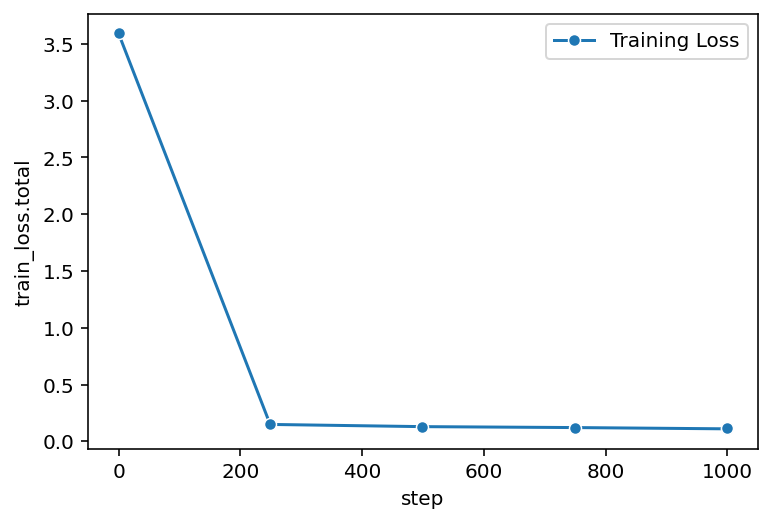

In [20]:
# Extract metrics and plot with seaborn

data = []
for step, metrics in metrics_saver.metrics:
  row = {'step': step}
  for key, v in metrics.train.items():
    row[f'train_{key}'] = v
  for key, v in metrics.eval.items():
    row[f'eval_{key}'] = v
  for key, v in metrics.eval_ema.items():
    row[f'eval_ema_{key}'] = v
  data.append(row)

df = pd.DataFrame(data)
sns.lineplot(data=df, x='step', y='train_loss.total', marker='o', label='Training Loss')


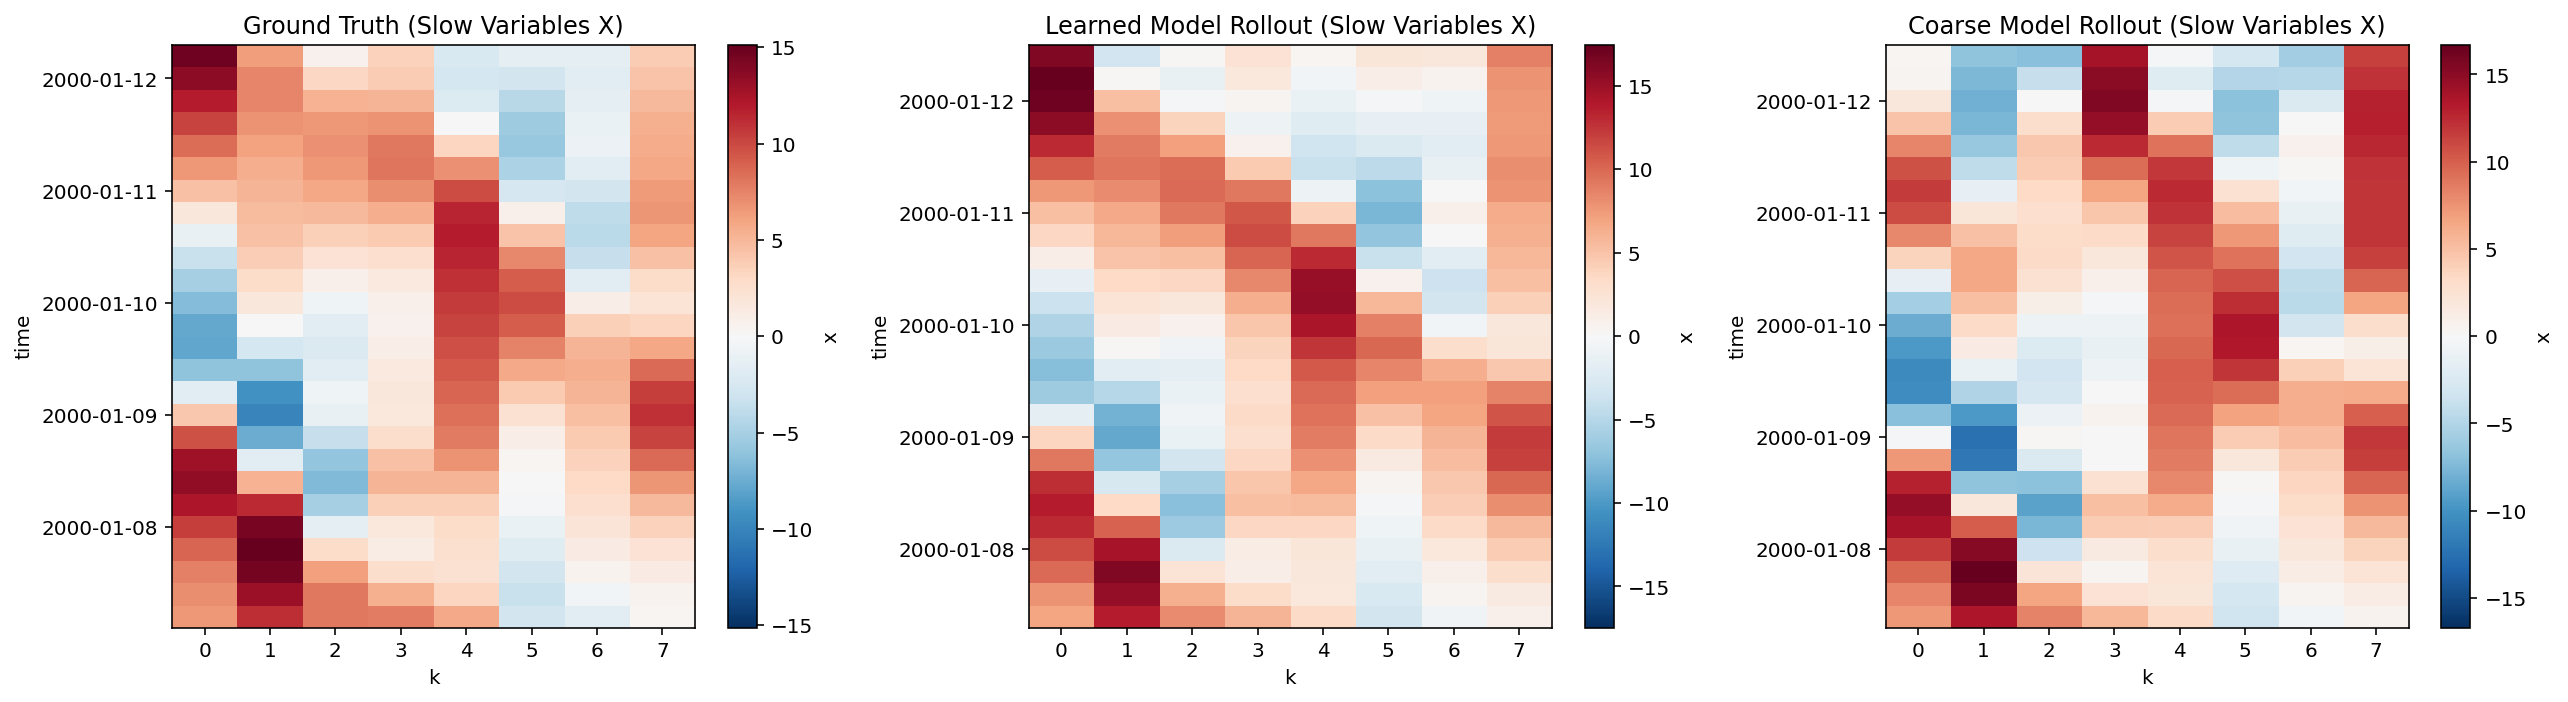

In [21]:
# Create inference model from the trained model
inference_model = api.InferenceModel.from_model_api(model)

# Baseline no parameterization coarse L96
l96_coarse = lorenz96.Lorenz96(
    k_axis=k,
    parameterizations=[],
    forcing=forcing,
    dt=dt_slow,
)
l96_coarse_inference_model = api.InferenceModel.from_model_api(l96_coarse)

# Take an initial state from the training data
initial_time = truth_ds.time.values[30]

init_inputs = xarray_utils.model_inputs_from_xarray(
    {'slow': truth_ds.sel(time=[initial_time])}, model
)

n_rollout_steps = 500 // fast_substeps
_, rollout_trajectory = api.forecast_steps(
    inference_model,
    init_inputs,
    rng=cx.field(jax.random.key(5)),
    timedelta=step_timedelta,
    steps=(n_rollout_steps + 1),
    queries={'slow': {'x': k, 'time': cx.Scalar()}}
)

_, coarse_model_trajectory = api.forecast_steps(
    l96_coarse_inference_model,
    init_inputs,
    rng=cx.field(jax.random.key(5)),
    timedelta=step_timedelta,
    steps=(n_rollout_steps + 1),
    queries={'slow': {'x': k, 'time': cx.Scalar()}}
)

# Convert to xarray
rollout_ds = xarray_utils.nested_fields_to_xarray(rollout_trajectory)
rollout_ds['slow'] = rollout_ds['slow'].swap_dims({'timedelta': 'time'}).set_coords('time')
rollout_ds['slow'].coords['time'] = initial_time + rollout_ds['slow'].coords['timedelta']

coarse_rollout_ds = xarray_utils.nested_fields_to_xarray(coarse_model_trajectory)
coarse_rollout_ds['slow'] = coarse_rollout_ds['slow'].swap_dims({'timedelta': 'time'}).set_coords('time')
coarse_rollout_ds['slow'].coords['time'] = initial_time + coarse_rollout_ds['slow'].coords['timedelta']


# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Ground Truth
targets_ds = truth_ds.sel(time=slice(initial_time, initial_time + n_rollout_steps * step_timedelta))
targets_ds['x'].plot.imshow(ax=ax1, x='k', y='time')
ax1.set_title('Ground Truth (Slow Variables X)')

# Rollout
rollout_ds['slow']['x'].plot.imshow(ax=ax2, x='k', y='time')
ax2.set_title('Learned Model Rollout (Slow Variables X)')

coarse_rollout_ds['slow']['x'].plot.imshow(ax=ax3, x='k', y='time')
ax3.set_title('Coarse Model Rollout (Slow Variables X)')

plt.tight_layout()
plt.show()

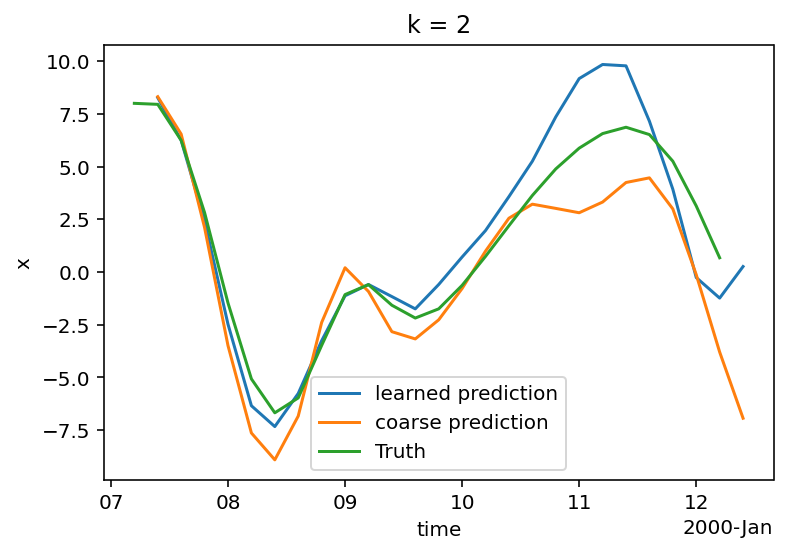

In [22]:
k_idx = 2
rollout_ds['slow']['x'].isel(k=k_idx).plot(x='time', label='learned prediction')
coarse_rollout_ds['slow']['x'].isel(k=k_idx).plot(x='time', label='coarse prediction')
targets_ds['x'].isel(k=k_idx).plot(x='time', label='Truth')
plt.legend()